In [1]:
import torch
import os

!pip install -q torch-geometric sentence-transformers python-louvain
import networkx as nx
import torch_geometric
from torch_geometric.data import Data, HeteroData
from sentence_transformers import SentenceTransformer
import community.community_louvain as louvain
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 947.8 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.9 MB/s eta 0:00:00a 0:00:01
PyTorch version: 2.10.0+cu128
PyG version: 2.7.0


In [2]:
import pickle
import networkx as nx
import os
import torch
from sentence_transformers import SentenceTransformer

input_path = "" 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.pkl'):
            input_path = os.path.join(dirname, filename)

if not input_path:
    raise FileNotFoundError("Could not find the .pkl file. Make sure the dataset is added to your notebook!")

print(f"Loading graph from: {input_path}")
with open(input_path, 'rb') as f:
    G = pickle.load(f)

print("Sanitizing node names...")
node_names = []
for n in G.nodes():
    name = G.nodes[n].get('name')
    if name is None or str(name).strip() == "":
        node_names.append("unknown_node")
    else:
        node_names.append(str(name))

print("Encoding features using SentenceTransformer... (GPU active)")
encoder = SentenceTransformer('all-MiniLM-L6-v2')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

node_features = encoder.encode(
    node_names, 
    convert_to_tensor=True, 
    device=device, 
    show_progress_bar=True
)

print(f"\nFeature Matrix Shape: {node_features.shape}")

Loading graph from: /kaggle/input/datasets/kanhashrikantkale/dermnet/dermnet_graph.pkl
Sanitizing node names...
Encoding features using SentenceTransformer... (GPU active)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/694 [00:00<?, ?it/s]


Feature Matrix Shape: torch.Size([22193, 384])


In [3]:
import torch
from torch_geometric.data import Data

node_mapping = {node_id: i for i, node_id in enumerate(G.nodes())}
edge_list = []
for u, v in G.edges():
    edge_list.append([node_mapping[u], node_mapping[v]])
    edge_list.append([node_mapping[v], node_mapping[u]])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

y = []
condition_mask = []
substance_ids = {node_mapping[n] for n, d in G.nodes(data=True) if d.get('label') == 'Substance'}

for n in G.nodes():
    is_condition = G.nodes[n].get('label') == 'Condition'
    condition_mask.append(is_condition)
    
    if is_condition:
        
        treatments = [node_mapping[nbr] for nbr in G.neighbors(n) if node_mapping[nbr] in substance_ids]
        y.append(1 if len(treatments) <= 1 else 0)
    else:
        y.append(0)

y = torch.tensor(y, dtype=torch.float).view(-1, 1)
mask = torch.tensor(condition_mask, dtype=torch.bool)
pyg_data = Data(x=node_features, edge_index=edge_index, y=y, train_mask=mask)
print(f"Data Object Ready:\n {pyg_data}")

Data Object Ready:
 Data(x=[22193, 384], edge_index=[2, 167560], y=[22193, 1], train_mask=[22193])


In [4]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class VulnerabilityModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return torch.sigmoid(x)

model = VulnerabilityModel(in_channels=384, hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCELoss()

In [5]:
# nlocking node features for AutoGrad
pyg_data.x = pyg_data.x.clone().detach().to(device)
pyg_data.edge_index = pyg_data.edge_index.to(device)
pyg_data.y = pyg_data.y.to(device)
pyg_data.train_mask = pyg_data.train_mask.to(device)

In [6]:
from tqdm.notebook import tqdm
import torch

model = VulnerabilityModel(in_channels=384, hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCELoss()

EPOCHS = 200
SAVE_PATH = 'vulnerability_model.pth'

model.train()
pbar = tqdm(range(EPOCHS), desc="Training GNN")

for epoch in pbar:
    optimizer.zero_grad()
    
    out = model(pyg_data.x, pyg_data.edge_index)
    loss = criterion(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    
    loss.backward()
    optimizer.step()
    
    if epoch % 5 == 0:
        pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

torch.save({
    'model_state_dict': model.state_dict(),
    'loss': loss.item(),
}, SAVE_PATH)

print(f"\nSuccess! Model saved to {SAVE_PATH}")

Training GNN:   0%|          | 0/200 [00:00<?, ?it/s]


Success! Model saved to vulnerability_model.pth


In [7]:
model.eval()
with torch.no_grad():

    predictions = model(pyg_data.x, pyg_data.edge_index)

risk_scores = predictions.cpu().numpy().flatten()

print(f"Generated risk scores for {len(risk_scores)} nodes.")

import pandas as pd

results = []

for node_id, idx in node_mapping.items():
    if G.nodes[node_id].get('label') == 'Condition':
        results.append({
            'Condition': G.nodes[node_id].get('name'),
            'Risk_Score': risk_scores[idx],
            'Actual_Vulnerability': pyg_data.y[idx].item()
        })

df_results = pd.DataFrame(results).sort_values(by='Risk_Score', ascending=False)

print("Top 10 Most Vulnerable Conditions (Predicted)")
print(df_results.head(10).to_string(index=False))

Generated risk scores for 22193 nodes.
Top 10 Most Vulnerable Conditions (Predicted)
                          Condition  Risk_Score  Actual_Vulnerability
                                 df    0.999958                   1.0
                               vasc    0.999951                   1.0
                              akiec    0.999942                   1.0
                                 nv    0.999928                   1.0
                                bcc    0.999907                   1.0
                                bkl    0.999877                   1.0
                                mel    0.999840                   1.0
                 Biliary Dyskinesia    0.999667                   1.0
Skin and Connective Tissue Diseases    0.999634                   1.0
                        Acne, Adult    0.999457                   1.0



Model Performance Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       111
         1.0       1.00      1.00      1.00        12

    accuracy                           1.00       123
   macro avg       1.00      1.00      1.00       123
weighted avg       1.00      1.00      1.00       123



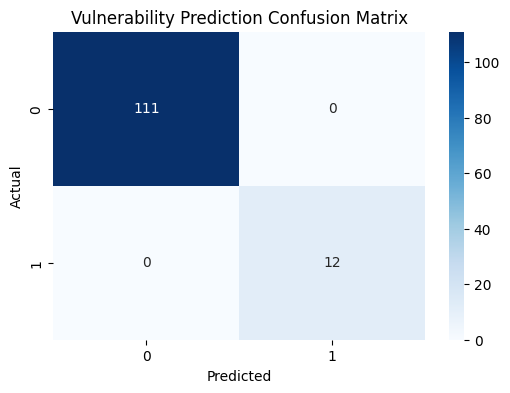

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = pyg_data.y[pyg_data.train_mask].cpu().numpy()
y_pred = (predictions[pyg_data.train_mask].cpu().numpy() > 0.5).astype(int)

print("\nModel Performance Report")
print(classification_report(y_true, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Vulnerability Prediction Confusion Matrix')
plt.show()

### Model 2, finding side effects

In [9]:
import torch_geometric.transforms as T
from torch_geometric.data import Data

device = 'cuda' if torch.cuda.is_available() else 'cpu'

transform = T.RandomLinkSplit(
    num_val=0.1, 
    num_test=0.1, 
    is_undirected=True, 
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    disjoint_train_ratio=0.3
)

train_data, val_data, test_data = transform(pyg_data.to(device))

print(f"Training Edges: {train_data.edge_index.shape[1]}")
print(f"Positive Supervision Edges: {train_data.edge_label.sum().item()}")

Training Edges: 93834
Positive Supervision Edges: 20107.0


In [10]:
from torch_geometric.nn import GCNConv

class SideEffectModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

model_se = SideEffectModel(in_channels=384, hidden_channels=128).to(device)
optimizer_se = torch.optim.Adam(model_se.parameters(), lr=0.01)
criterion_se = torch.nn.BCEWithLogitsLoss()

In [11]:
from tqdm.notebook import tqdm

def train_link_predictor():
    model_se.train()
    pbar = tqdm(range(150), desc="Discovering Links")
    
    for epoch in pbar:
        optimizer_se.zero_grad()
        
        z = model_se.encode(train_data.x, train_data.edge_index)
        predictions = model_se.decode(z, train_data.edge_label_index)
        loss = criterion_se(predictions, train_data.edge_label)
        loss.backward()
        optimizer_se.step()
        if epoch % 10 == 0:
            pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

train_link_predictor()
SE_MODEL_PATH = 'side_effect_model.pth'
torch.save({
    'model_state_dict': model_se.state_dict(),
    'optimizer_state_dict': optimizer_se.state_dict(),
    'loss': loss.item() if 'loss' in locals() else "N/A",
}, SE_MODEL_PATH)

print(f"Side-Effect")
model_se.eval()
with torch.no_grad():
    z = model_se.encode(test_data.x, test_data.edge_index)

def predict_side_effects(substance_name, top_n=5):
    sub_id = next(i for i, n in node_mapping.items() if G.nodes[n].get('name') == substance_name)
    sub_idx = node_mapping[sub_id]
    condition_indices = [node_mapping[n] for n, d in G.nodes(data=True) if d.get('label') == 'Condition']
    sub_tensor = torch.full((len(condition_indices),), sub_idx, dtype=torch.long, device=device)
    cond_tensor = torch.tensor(condition_indices, dtype=torch.long, device=device)
    query_edges = torch.stack([sub_tensor, cond_tensor])
    scores = torch.sigmoid(model_se.decode(z, query_edges)).cpu().numpy()
    results = []
    for idx, score in enumerate(scores):
        cond_node_id = list(G.nodes())[condition_indices[idx]]
        results.append((G.nodes[cond_node_id].get('name'), score))
    
    return sorted(results, key=lambda x: x[1], reverse=True)[:top_n]
print(f"Top Predicted Side Effects for Picoxystrobin:")
print(predict_side_effects('picoxystrobin'))

Discovering Links:   0%|          | 0/150 [00:00<?, ?it/s]

Side-Effect
Top Predicted Side Effects for Picoxystrobin:
[('Skin Neoplasms', np.float32(1.0)), ('Melanoma', np.float32(1.0)), ('Psoriasis', np.float32(1.0)), ('Dermatitis, Allergic Contact', np.float32(1.0)), ('Dermatitis, Contact', np.float32(1.0))]


In [12]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_link_prediction(model, data):
    model.eval()
    with torch.no_grad():
        z = model.encode(data.x, data.edge_index)
        out = model.decode(z, data.edge_label_index).view(-1).sigmoid()
        y_true = data.edge_label.cpu().numpy()
        y_pred = out.cpu().numpy()
        auc = roc_auc_score(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        
    print(f"📈 Test AUC-ROC: {auc:.4f}")
    print(f"📈 Test Avg Precision: {ap:.4f}")
    return y_true, y_pred
y_true, y_pred = evaluate_link_prediction(model_se, test_data)

📈 Test AUC-ROC: 0.9988
📈 Test Avg Precision: 0.9990


In [13]:
import pandas as pd
def generate_master_risk_report(substance_name):
    se_predictions = predict_side_effects(substance_name, top_n=10)
    master_data = []
    for cond_name, se_score in se_predictions:
        node_id = next(n for n, d in G.nodes(data=True) if d.get('name') == cond_name)
        idx = node_mapping[node_id]
        vulnerability_score = risk_scores[idx]
        master_data.append({
            'Predicted_Side_Effect': cond_name,
            'Side_Effect_Probability': f"{se_score*100:.2f}%",
            'Condition_Vulnerability': f"{vulnerability_score*100:.2f}%",
            'Total_Threat_Index': (se_score + vulnerability_score) / 2
        })
    df_master = pd.DataFrame(master_data).sort_values(by='Total_Threat_Index', ascending=False)
    return df_master
master_report = generate_master_risk_report('picoxystrobin')
print(f"Master Clinical Risk Report: Picoxystrobin")
print(master_report.to_string(index=False))

Master Clinical Risk Report: Picoxystrobin
       Predicted_Side_Effect Side_Effect_Probability Condition_Vulnerability  Total_Threat_Index
         Dermatitis, Contact                 100.00%                   0.00%            0.500004
                   Psoriasis                 100.00%                   0.00%            0.500004
                    Melanoma                 100.00%                   0.00%            0.500004
              Skin Neoplasms                 100.00%                   0.00%            0.500004
    Dyskinesia, Drug-Induced                 100.00%                   0.00%            0.500003
             Dermatomyositis                 100.00%                   0.00%            0.500003
                  Dermatitis                 100.00%                   0.00%            0.500002
Dermatitis, Allergic Contact                 100.00%                   0.00%            0.500002
               Skin Diseases                 100.00%                   0.00%        

In [14]:
device = node_features.device 
print(f"Using device: {device}")

model_se = model_se.to(device)
edge_index = edge_index.to(device)

model_se.eval()
with torch.no_grad():

    z = model_se.encode(node_features, edge_index)
    
    node_list = list(G.nodes())
    bpa_idx = next(i for i, n in enumerate(node_list) if G.nodes[n].get('name') == 'bisphenol A')
    acne_idx = next(i for i, n in enumerate(node_list) if G.nodes[n].get('name') == 'Acne, Adult')
    prob = torch.sigmoid((z[bpa_idx] * z[acne_idx]).sum(dim=-1)).item()
    print(f"\n📊 --- BPA Stress Test Result ---")
    print(f"Path: BPA -> Adult Acne")
    print(f"Confidence Score: {prob:.4f}")

Using device: cuda:0

📊 --- BPA Stress Test Result ---
Path: BPA -> Adult Acne
Confidence Score: 0.9964
